# Gradient Descent on a Quadratic

**Goal.** Connect curvature to stable step sizes before studying ML-specific optimizers.
Understand how Hessian eigenvalues control convergence, and why ill-conditioning causes zigzag.


In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)


## HOW

For $f(w)=\frac12w^\top Hw$ with positive-definite $H$, the gradient is $\nabla f = Hw$.

GD update: $w_{t+1} = w_t - \eta H w_t = (I - \eta H) w_t$

Error dynamics: $e_{t+1} = (I - \eta H) e_t$ where $e_t = w_t - w^*$.

**Stability condition:** all eigenvalues of $(I - \eta H)$ must have $|1 - \eta\lambda_i| < 1$,
which gives $0 < \eta < 2/\lambda_{\max}(H)$.


## Experiment 1: Stability boundary

With $H = \text{diag}(1, 8)$, the stable range is $0 < \eta < 2/8 = 0.25$.
We test three learning rates: one slow, one near-optimal, one divergent.


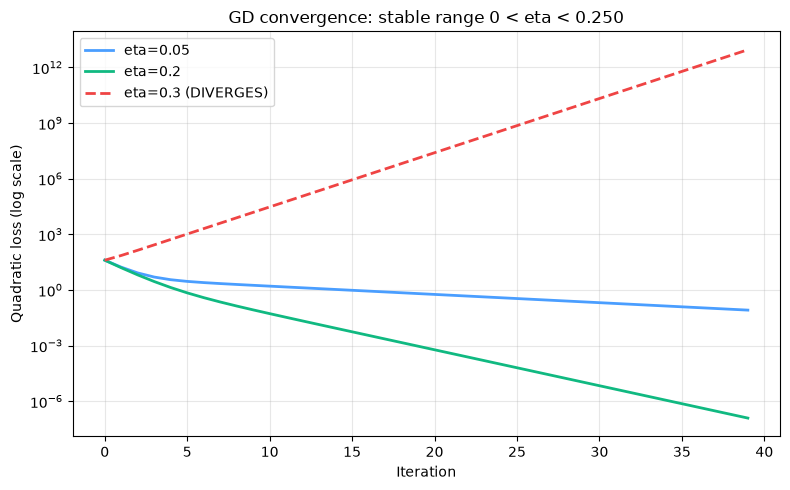

Eigenvalues: [1. 8.]
Condition number: 8.0
Stable interval: 0 < eta < 0.250
Assertions passed.


In [2]:
H = np.diag([1.0, 8.0])
stable_upper_bound = 2.0 / np.linalg.eigvalsh(H).max()

def run(H_mat, step_size, w0=None, steps=40):
    """Run GD on f(w) = 0.5 * w^T H w, return losses."""
    if w0 is None:
        w0 = np.array([3.0, 3.0])
    w = w0.copy()
    losses = []
    for _ in range(steps):
        losses.append(0.5 * w @ H_mat @ w)
        w = w - step_size * (H_mat @ w)
    return np.array(losses)

fig, ax = plt.subplots(figsize=(8, 5))
for eta, color, ls in [(0.05, '#4a9eff', '-'), (0.2, '#10b981', '-'), (0.3, '#ef4444', '--')]:
    losses = run(H, eta)
    label = f'eta={eta}'
    if eta > stable_upper_bound:
        label += ' (DIVERGES)'
    ax.plot(losses, label=label, color=color, ls=ls, lw=2)

ax.set_yscale('log')
ax.set_xlabel('Iteration')
ax.set_ylabel('Quadratic loss (log scale)')
ax.set_title(f'GD convergence: stable range 0 < eta < {stable_upper_bound:.3f}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Eigenvalues: {np.linalg.eigvalsh(H)}')
print(f'Condition number: {np.linalg.eigvalsh(H).max()/np.linalg.eigvalsh(H).min():.1f}')
print(f'Stable interval: 0 < eta < {stable_upper_bound:.3f}')
assert run(H, 0.2)[-1] < run(H, 0.2)[0], 'eta=0.2 should converge'
assert run(H, 0.3)[-1] > run(H, 0.3)[0], 'eta=0.3 should diverge'
print('Assertions passed.')


## Optimal learning rate

For a quadratic, the optimal learning rate (fastest convergence) is:

$$\eta^* = \frac{2}{\lambda_{\min} + \lambda_{\max}}$$

This balances the convergence rates of the fastest and slowest eigendirections.
The resulting convergence rate is $r = (\kappa - 1)/(\kappa + 1)$ where $\kappa = \lambda_{\max}/\lambda_{\min}$.


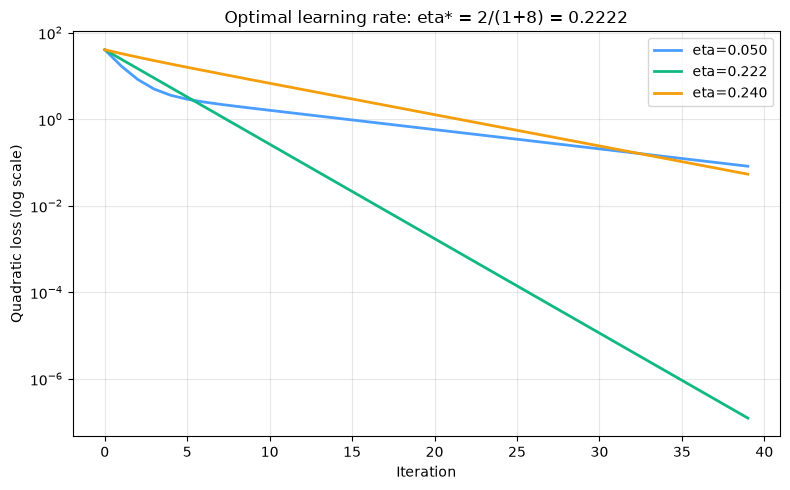

Optimal eta: 0.2222
Condition number: 8.0
Convergence rate: r = 0.7778
Optimal eta converges fastest. Verified.


In [3]:
eigs = np.linalg.eigvalsh(H)
eta_optimal = 2.0 / (eigs.min() + eigs.max())
kappa = eigs.max() / eigs.min()
conv_rate = (kappa - 1) / (kappa + 1)

# Compare: sub-optimal, optimal, near-boundary
fig, ax = plt.subplots(figsize=(8, 5))
etas = [0.05, eta_optimal, 0.24]
colors = ['#4a9eff', '#10b981', '#f59e0b']
for eta, color in zip(etas, colors):
    losses = run(H, eta)
    ax.plot(losses, label=f'eta={eta:.3f}', color=color, lw=2)

ax.set_yscale('log')
ax.set_xlabel('Iteration')
ax.set_ylabel('Quadratic loss (log scale)')
ax.set_title(f'Optimal learning rate: eta* = 2/(1+8) = {eta_optimal:.4f}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Optimal eta: {eta_optimal:.4f}')
print(f'Condition number: {kappa:.1f}')
print(f'Convergence rate: r = {conv_rate:.4f}')

# Verify optimal converges faster than sub-optimal
assert run(H, eta_optimal)[-1] < run(H, 0.05)[-1]
assert run(H, eta_optimal)[-1] < run(H, 0.24)[-1]
print('Optimal eta converges fastest. Verified.')


## 2D trajectory visualization

GD paths on the contour plot of $f(x,y) = \frac{1}{2}(x^2 + 8y^2)$.
Different learning rates show: slow progress, optimal path, and zigzag near stability limit.


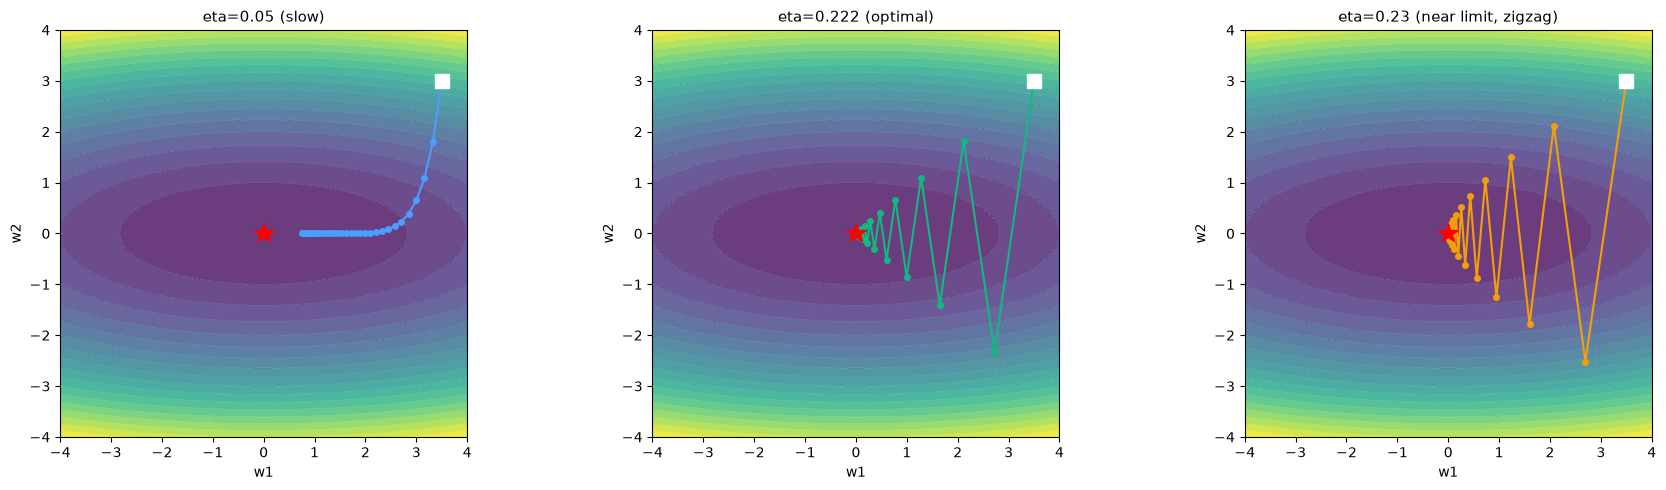

In [4]:
def gd_trajectory(H_mat, w0, lr, n_steps):
    """Run GD and return full trajectory."""
    path = [w0.copy()]
    w = w0.copy()
    for _ in range(n_steps):
        w = w - lr * (H_mat @ w)
        path.append(w.copy())
    return np.array(path)

grid = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(grid, grid)
Z = 0.5 * (X**2 + 8 * Y**2)

w0 = np.array([3.5, 3.0])
trajectories = [
    (0.05, '#4a9eff', 'eta=0.05 (slow)'),
    (eta_optimal, '#10b981', f'eta={eta_optimal:.3f} (optimal)'),
    (0.23, '#f59e0b', 'eta=0.23 (near limit, zigzag)'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (lr, color, title) in zip(axes, trajectories):
    ax.contourf(X, Y, Z, levels=20, cmap='viridis', alpha=0.8)
    ax.contour(X, Y, Z, levels=20, colors='white', linewidths=0.3, alpha=0.5)
    path = gd_trajectory(H, w0, lr, 30)
    ax.plot(path[:, 0], path[:, 1], 'o-', color=color, ms=4, lw=1.5)
    ax.plot(*w0, 'ws', ms=10, zorder=5)
    ax.plot(0, 0, 'r*', ms=15, zorder=5)
    ax.set_xlabel('w1')
    ax.set_ylabel('w2')
    ax.set_title(title, fontsize=11)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()


## Condition number experiment

Three quadratics with different condition numbers ($\kappa$).
Each uses its own optimal learning rate $\eta^* = 2/(\lambda_{\min} + \lambda_{\max})$.
Convergence rate: $r = (\kappa - 1)/(\kappa + 1)$.


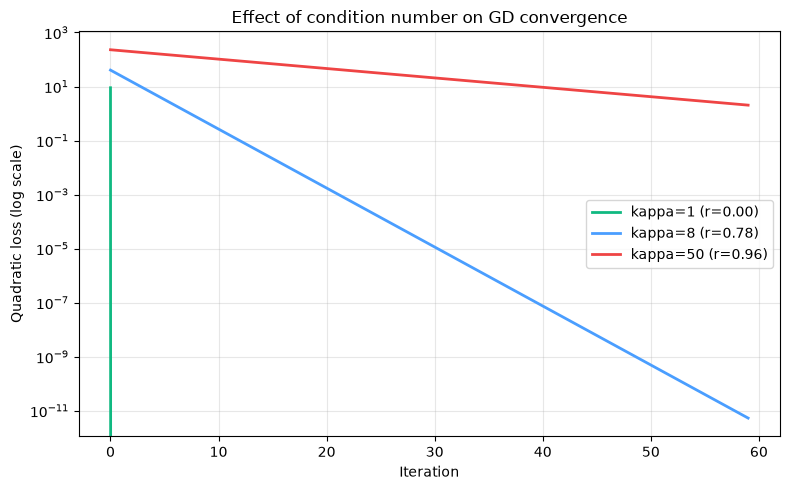

Key insight: higher kappa -> slower convergence, even with optimal learning rate.
This is the fundamental limitation that motivates momentum and adaptive methods.


In [5]:
experiments = [
    (np.diag([1.0, 1.0]),  'kappa=1',  '#10b981'),   # perfect conditioning
    (np.diag([1.0, 8.0]),  'kappa=8',  '#4a9eff'),   # moderate
    (np.diag([1.0, 50.0]), 'kappa=50', '#ef4444'),   # ill-conditioned
]

fig, ax = plt.subplots(figsize=(8, 5))
for H_exp, label, color in experiments:
    eig_exp = np.linalg.eigvalsh(H_exp)
    eta_exp = 2.0 / (eig_exp.min() + eig_exp.max())
    kappa_exp = eig_exp.max() / eig_exp.min()
    rate_exp = (kappa_exp - 1) / (kappa_exp + 1)
    losses_exp = run(H_exp, eta_exp, steps=60)
    ax.plot(losses_exp, label=f'{label} (r={rate_exp:.2f})', color=color, lw=2)

ax.set_yscale('log')
ax.set_xlabel('Iteration')
ax.set_ylabel('Quadratic loss (log scale)')
ax.set_title('Effect of condition number on GD convergence')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Key insight: higher kappa -> slower convergence, even with optimal learning rate.')
print('This is the fundamental limitation that motivates momentum and adaptive methods.')


## Result

1. **Stable range** depends on $\lambda_{\max}$: must have $\eta < 2/\lambda_{\max}$, otherwise GD diverges.
2. **Optimal $\eta$** depends on both eigenvalues: $\eta^* = 2/(\lambda_{\min} + \lambda_{\max})$ -- cannot compute in practice without knowing the spectrum.
3. **Condition number** $\kappa$ determines convergence speed: high $\kappa$ = slow convergence + zigzag, even with optimal $\eta$.
4. These limitations motivate **momentum** (reduces zigzag) and **adaptive methods** (Adam: per-dimension scaling).


## CONNECTIONS

The [Gradient Descent topic](../../topics/02_gradient_descent/README.md) extends this deterministic quadratic picture to stochastic gradients, momentum, Adam, and failure cases.

See also:
- [optimization_landscape.ipynb](./optimization_landscape.ipynb): 2D contour + GD trajectory demo
- [taylor_approximation.ipynb](./taylor_approximation.ipynb): quadratic = local Taylor approximation near minimum
- [derivatives_gradients.md](./derivatives_gradients.md): Hessian definition, condition number, gradient flow
